In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("C:/Users/ELCOT/Downloads/Car_sales_data(1).xlsx")
df=pd.read_excel(r"C:\Users\ELCOT\Downloads\Car_sales_data(1).xlsx")
print(df)
print(df.head())
print(df.head(200))
print(df.tail())
print(df.tail(200))
print(df.info())
print(df.describe())
print(df.shape[0])
print(df.shape[1])
print(df['Make'])
print(df[['Model','Year','Fuel Type']])
print(df.iloc[1])
print(df.Year)

           Make     Model  Year Fuel Type Transmission Customer ID  \
0        Toyota   Corolla  2024    Petrol       Manual    CUST9953   
1          Audi        A3  2024    Petrol    Automatic    CUST5065   
2        Toyota     Camry  2020    Hybrid       Manual    CUST1118   
3        Nissan    Sentra  2020    Diesel    Automatic    CUST4834   
4          Audi        Q7  2019    Petrol    Automatic    CUST7190   
...         ...       ...   ...       ...          ...         ...   
1995  Chevrolet  Traverse  2015  Electric       Manual    CUST6369   
1996  Chevrolet     Tahoe  2018    Petrol       Manual    CUST2732   
1997     Nissan     Rogue  2021    Diesel    Automatic    CUST6842   
1998       Ford  Explorer  2020    Diesel    Automatic    CUST6224   
1999     Nissan    Murano  2019    Diesel       Manual    CUST7243   

     Customer Location  Customer Age Customer Gender  Sale Price  ...  \
0          Los Angeles            60          Female    29569.57  ...   
1          Lo

'Total_numbers_of_row=(df.shape[0])\nprint(Total_numbers_of_row)\nTotal_numbers_of_column=(df.shape[1])\nprint(Total_numbers_of_column)\nTotal_sale_amount = df[\'Final Price\'].sum()\nprint(Total_sale_amount)\nvalue = 87324368.50999999\nshort = value /1_000_000\nprint(f"{short:.2f}M")\nHighest_price_car = df.loc[df[\'Sale Price\'].idxmax()]\nprint(Highest_price_car)\nLowest_price_car = df.loc[df[\'Sale Price\'].idxmin()]\nprint(Lowest_price_car)\navg_price_by_dealer = df.groupby(\'Dealer Name\')[\'Sale Price\'].mean()\nprint(avg_price_by_dealer)'

In [10]:
Total_numbers_of_row=(df.shape[0])
print(Total_numbers_of_row)
Total_numbers_of_column=(df.shape[1])
print(Total_numbers_of_column)
Total_sale_amount = df['Final Price'].sum()
print(Total_sale_amount)
value = 87324368.50999999
short = value /1_000_000
print(f"{short:.2f}M")
Highest_price_car = df.loc[df['Sale Price'].idxmax()]
print(Highest_price_car)
Lowest_price_car = df.loc[df['Sale Price'].idxmin()]
print(Lowest_price_car)
avg_price_by_dealer = df.groupby('Dealer Name')['Sale Price'].mean()
print(avg_price_by_dealer)

2000
24
87324368.50999999
87.32M
Make                                   Kia
Model                               Seltos
Year                                  2020
Fuel Type                           Petrol
Transmission                     Automatic
Customer ID                       CUST2312
Customer Location            San Francisco
Customer Age                            70
Customer Gender                       Male
Sale Price                        79973.71
Discount                            2906.4
Taxes                               6397.9
Final Price                       83465.21
Payment Method               Financed Loan
Registration Number              REG-76592
Registration Date      2023-01-02 00:00:00
Expiry Date            2026-08-29 00:00:00
Dealer Name                      DriveTime
Dealer Location                     Denver
Ownership Status                      Used
Warranty Period                No Warranty
Loan Status                       Rejected
Insurance Provider   

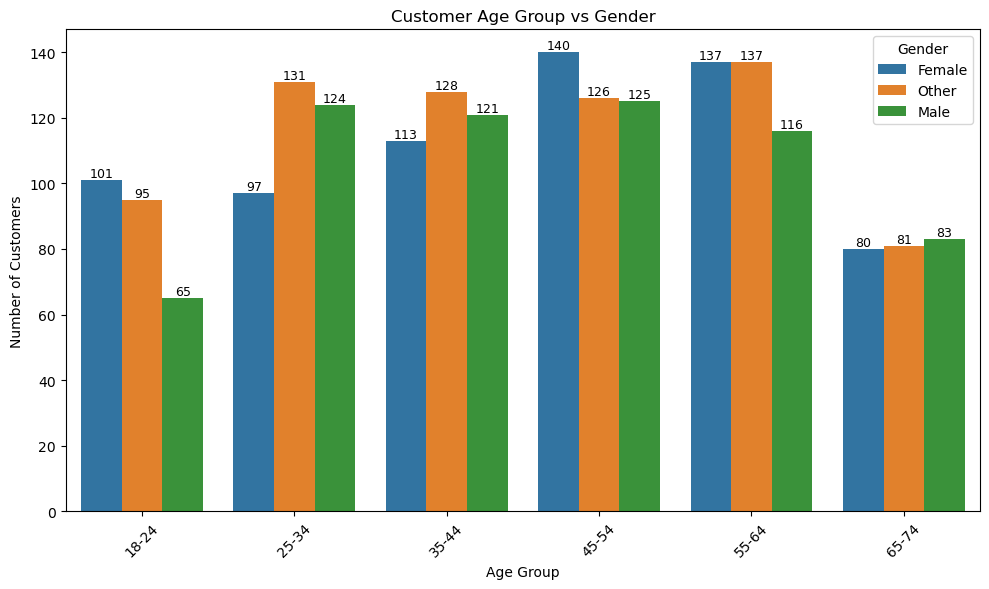

In [3]:
#Seaborn(Count)
age_bins = [18, 25, 35, 45, 55, 65, 75]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']
df['Age Group'] = pd.cut(df['Customer Age'], bins=age_bins, labels=age_labels, right=False)
plt.figure(figsize=(10,6))
ax = sns.countplot(data=df,x='Age Group',hue='Customer Gender')
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.title("Customer Age Group vs Gender")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

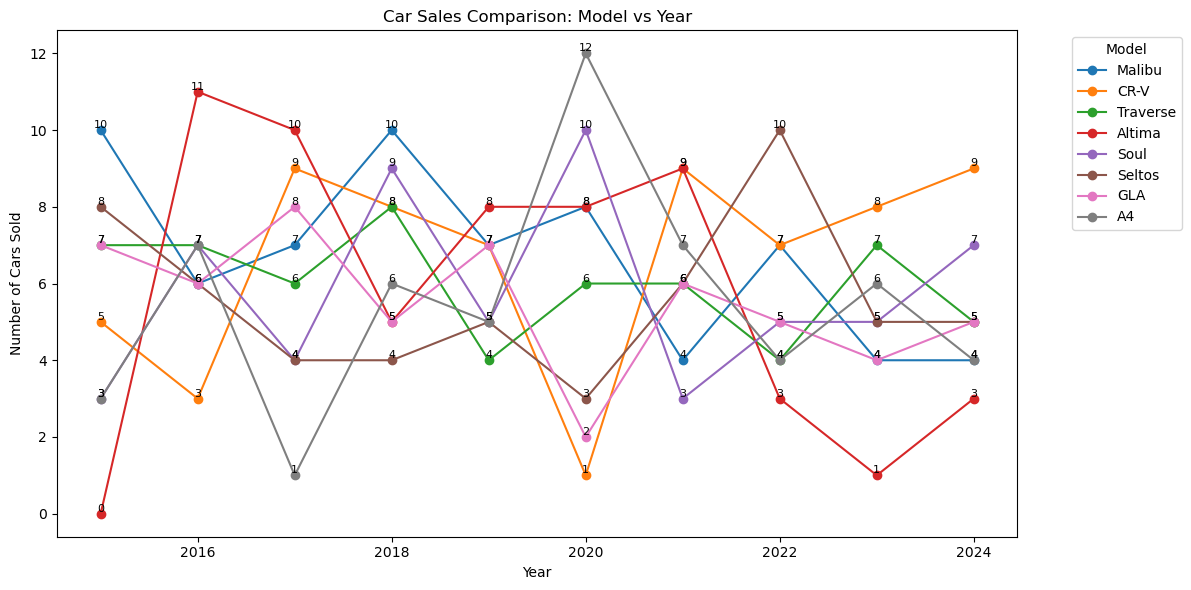

In [11]:
#Line chart
model_year = pd.crosstab(df['Year'], df['Model'])
top_models = df['Model'].value_counts().head(8).index
model_year = model_year[top_models]
plt.figure(figsize=(12,6))
ax = model_year.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Car Sales Comparison: Model vs Year")
plt.xlabel("Year")
plt.ylabel("Number of Cars Sold")
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x, y, str(int(y)), fontsize=8, ha='center', va='bottom')
plt.tight_layout()
plt.show()

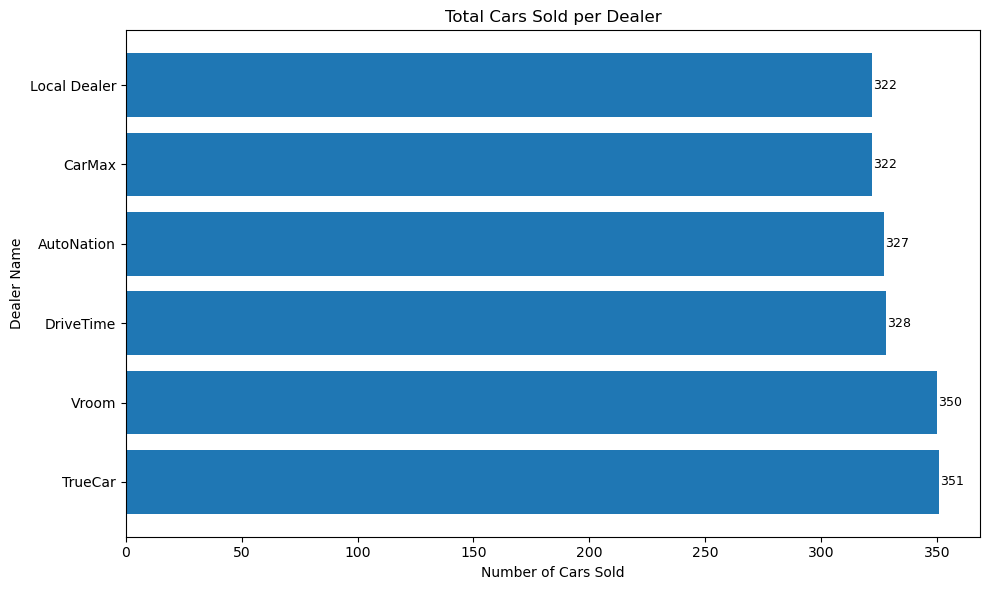

In [4]:
#BarH Chart:
dealer_sales = df['Dealer Name'].value_counts().head(10)
plt.figure(figsize=(10,6))
bars = plt.barh(dealer_sales.index, dealer_sales.values)
plt.title("Total Cars Sold per Dealer")
plt.xlabel("Number of Cars Sold")
plt.ylabel("Dealer Name")
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5,bar.get_y() + bar.get_height()/2,str(int(width)),                  
             va='center', fontsize=9,color='black')
#plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

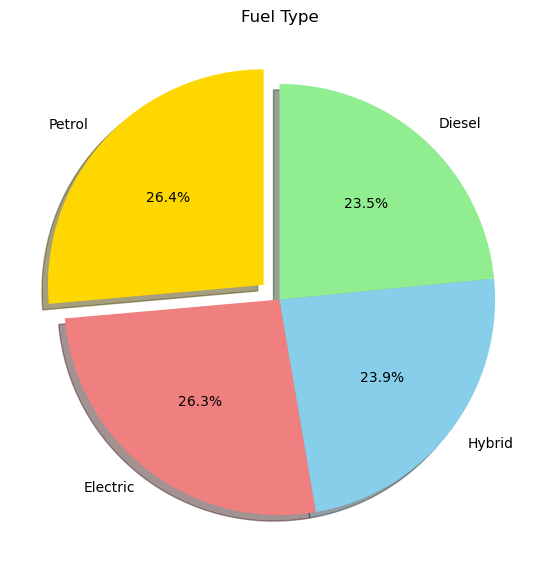

'fuel_counts = df[\'Fuel Type\'].value_counts()\ncolors=[\'gold\',\'lightcoral\',\'skyblue\',\'lightgreen\']\nplt.figure(figsize=(7,7))\nplt.pie(\n    fuel_counts.values,\n    labels=fuel_counts.index,\n    autopct=\'%1.1f%%\',\n    colors=colors,startangle=90,wedgeprops={\'width\': 0.6})\nplt.text(0,0,"Fuel\nPreference", ha=\'center\',va=\'center\', fontsize=14, fontweight=\'bold\')\nplt.title("Fuel Type Preference (Donut Chart)")\nplt.legend(fuel_counts.index, title="Fuel Types",loc=\'best\',bbox_to_anchor=(1.2,1))\nplt.show()'

In [5]:
#Pie Chart:
fuel_counts = df['Fuel Type'].value_counts()
colors=['gold','lightcoral','skyblue','lightgreen']
explode=[0.1,0,0,0]
plt.figure(figsize=(7,7))
plt.pie(fuel_counts.values,labels=fuel_counts.index, autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,startangle=90
)
plt.title("Fuel Type")
plt.show()

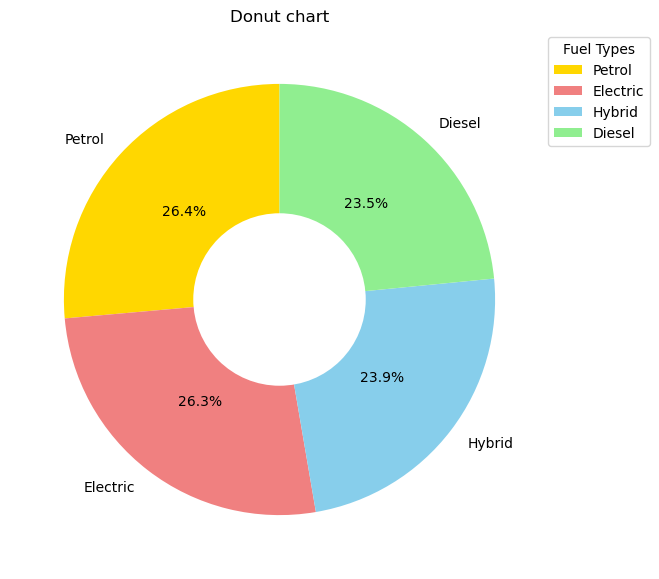

In [6]:
fuel_counts = df['Fuel Type'].value_counts()
colors=['gold','lightcoral','skyblue','lightgreen']
plt.figure(figsize=(7,7))
plt.pie(fuel_counts.values,labels=fuel_counts.index, autopct='%1.1f%%',
    colors=colors,startangle=90)
center_circle=plt.Circle((0,0),0.40,fc='white')
plt.legend(fuel_counts.index, title="Fuel Types",loc='best',bbox_to_anchor=(1.2,1))
plt.gca().add_artist(center_circle)
plt.title("Donut chart")
plt.show()

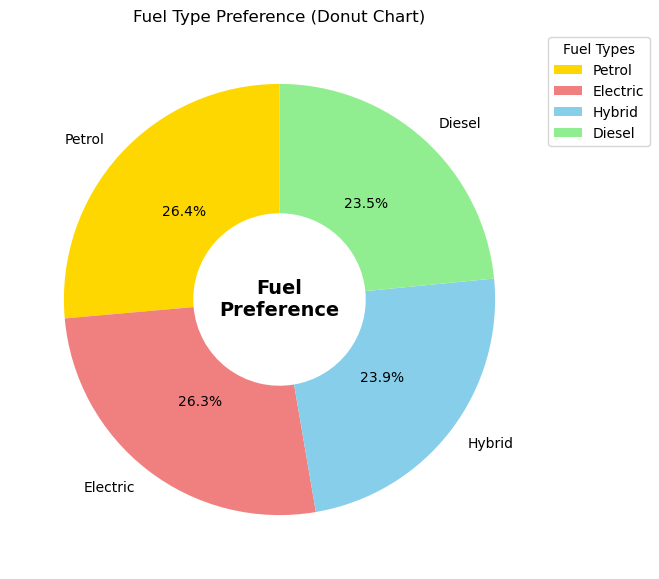

In [7]:
fuel_counts = df['Fuel Type'].value_counts()
colors=['gold','lightcoral','skyblue','lightgreen']
plt.figure(figsize=(7,7))
plt.pie(
    fuel_counts.values,
    labels=fuel_counts.index,
    autopct='%1.1f%%',
    colors=colors,startangle=90,wedgeprops={'width': 0.6})
plt.text(0,0,"Fuel\nPreference", ha='center',va='center', fontsize=14, fontweight='bold')
plt.title("Fuel Type Preference (Donut Chart)")
plt.legend(fuel_counts.index, title="Fuel Types",loc='best',bbox_to_anchor=(1.2,1))
plt.show()



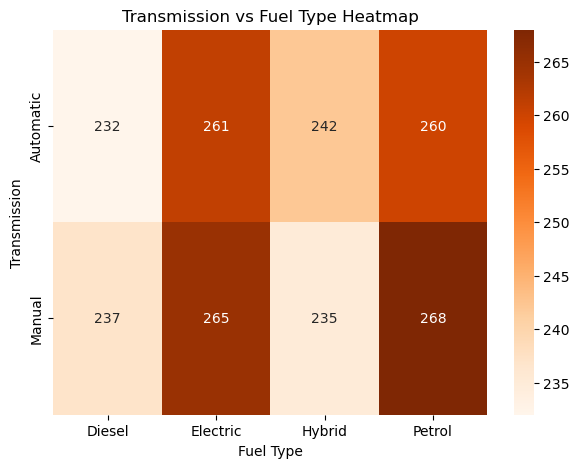

In [8]:
#Heat map
table = pd.crosstab(df['Transmission'], df['Fuel Type'])
plt.figure(figsize=(7,5))
sns.heatmap(table, annot=True, fmt='d', cmap='Oranges')
plt.title("Transmission vs Fuel Type Heatmap")
plt.show()


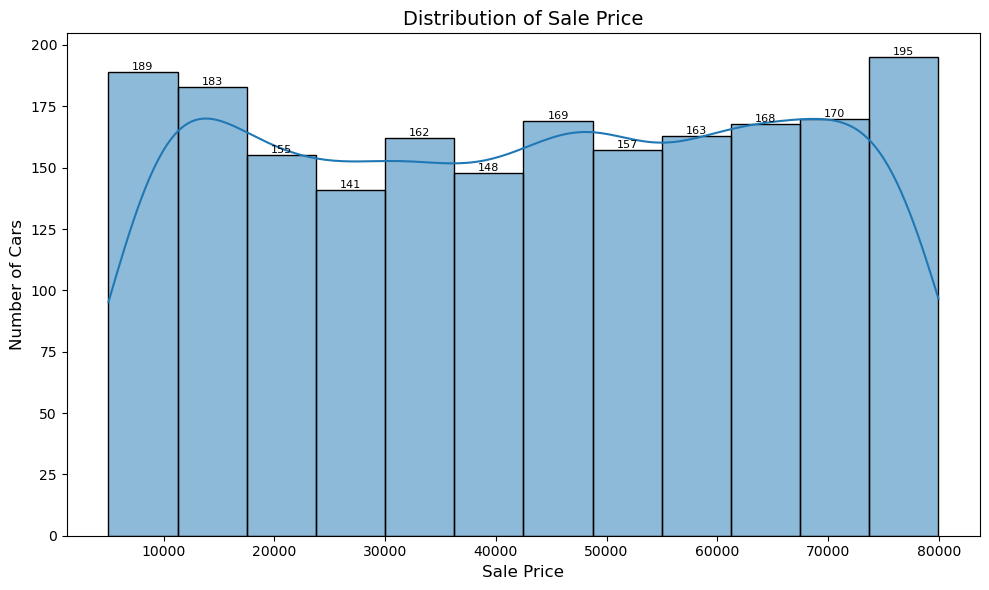

In [9]:
#Hist plot
plt.figure(figsize=(10,6))
ax = sns.histplot(df['Sale Price'], kde=True)
plt.title("Distribution of Sale Price", fontsize=14)
plt.xlabel("Sale Price", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center', va='bottom', fontsize=8
        )
plt.tight_layout()
plt.show()